# Assignment 2

In [118]:
import pandas as pd

# Specify the path to your CSV file
csv_path = "query_product.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_path, encoding="latin1")
desc = pd.read_csv('product_descriptions.csv', encoding='latin1')
df = df.merge(desc, on='product_uid', how='left')

In [119]:
df['relevance'].describe()

count    74067.000000
mean         2.381634
std          0.533984
min          1.000000
25%          2.000000
50%          2.330000
75%          3.000000
max          3.000000
Name: relevance, dtype: float64

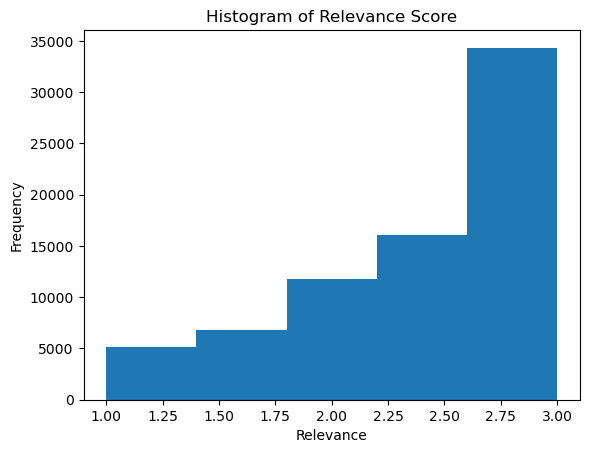

In [120]:
import matplotlib.pyplot as plt

# Assuming you have a DataFrame named data_frame
# and you want to visualize a column named 'column_name'

# Create a histogram of the column's values
plt.hist(df['relevance'], bins=5)

# Add labels and title
plt.xlabel('Relevance')
plt.ylabel('Frequency')
plt.title('Histogram of Relevance Score')

# Display the plot
plt.show()

In [121]:
from sklearn.model_selection import train_test_split


# Set the training size
training_size = 50000

# Split the DataFrame into training and test sets
train_data, test_data = train_test_split(df, test_size=(len(df) - training_size), random_state=42)

# Display the training data
train_data

# Display the test data
test_data

,id,product_uid,product_title,search_term,relevance,product_description
13534,41864,110074,DEWALT 20-Volt Max Lithium-Ion Cordless Combo ...,commercial cordless drill set,3.00,The DEWALT DCKTS240C2 Combo kit is versatile e...
29748,91116,127729,Cerrowire 15 Amp 125-Volt Stay Plugged Replace...,15 Amp Extension Cord,2.67,This black and yellow Stay Plug Cord replaceme...
20225,62389,116912,Broan Allure 2 Series 30 in. Convertible Range...,30 inch under cabinet stainless range hood,2.67,The BroanAllureII line of range hoods feature ...
5169,16212,102866,Gardner Bender 1/2 in. Black Polyolefin Heat S...,heat shrink tubing,2.67,The 1/2 in. Black Polyolefin Heat Shrink Tubin...
49860,151456,156894,Stainless Glide Stainless Steel Strap Rolling ...,stainless steel hardware,2.00,The Stainless Glide Stainless Steel Rolling Do...
...,...,...,...,...,...,...
16502,50892,113039,Roberts 360 sq. ft. Felt Cushion Underlayment ...,underlayment for laminate flooring,3.00,The Roberts 70-193 super felt premium underlay...
54982,166615,165859,Steves &amp; Sons 36 in. x 80 in. Premium 1-Pa...,steves and sons 6panel white,2.33,The Steves and Sons Premium 1-Panel with high-...
60036,181204,175353,Sterilite 12 Gal. Latch and Carry Tote (6-Pack),carrrs,2.00,The 12 Gal. Latch and Carry Clear is great for...
22047,68083,118908,iTouchless Bio-Matic Fingerprint Gold Right Ha...,fingerprint lock,3.00,Save your family the need to carry bulky key c...


In [122]:
train_data['query_words'] = train_data['search_term'].apply(lambda x: set(x.lower().split()))
train_data['title_words'] = train_data['product_title'].apply(lambda x: set(x.lower().split()))
test_data['query_words']  = test_data['search_term'].apply(lambda x: set(x.lower().split()))
test_data['title_words']  = test_data['product_title'].apply(lambda x: set(x.lower().split()))

def check_words(row):
    return int(row['query_words'].issubset(row['title_words']))

def frac_words_in_title(row):
    if not row['query_words']: return 0
    return len(row['query_words'] & row['title_words']) / len(row['query_words'])

def query_length(row):
    return len (row['search_term'].lower().split())

def frac_words_in_desc(row):
    words_desc = set(str(row['product_description']).lower().split())
    if not row['query_words']: return 0
    return len(row['query_words'] & words_desc) / len(row['query_words'])

def title_length(row):
    return len(row['title_words'])

def n_words_in_title(row):
    return len(row['query_words'] & row['title_words'])

def exact_match(row):
    query = row['search_term'].lower()
    title = row['product_title'].lower()
    return int(query in title)

def desc_length(row):
    return len(str(row['product_description']).lower().split())

train_data['all_words_in_title'] = train_data.apply(check_words, axis=1)
train_data['frac_words_in_title'] = train_data.apply(frac_words_in_title, axis=1)
train_data['query_length'] = train_data.apply(query_length, axis=1)
train_data['frac_words_in_desc'] = train_data.apply(frac_words_in_desc, axis=1)
train_data['title_length'] = train_data.apply(title_length, axis=1)
train_data['n_words_in_title'] = train_data.apply(n_words_in_title, axis=1)
train_data['exact_match'] = train_data.apply(exact_match, axis=1)
train_data['desc_length'] = train_data.apply(desc_length, axis=1)

test_data['all_words_in_title'] = test_data.apply(check_words, axis=1)
test_data['frac_words_in_title'] = test_data.apply(frac_words_in_title, axis=1)
test_data['query_length'] = test_data.apply(query_length, axis=1)
test_data['frac_words_in_desc']  = test_data.apply(frac_words_in_desc, axis=1)
test_data['title_length'] = test_data.apply(title_length, axis=1)
test_data['n_words_in_title'] = test_data.apply(n_words_in_title, axis=1)
test_data['exact_match'] = test_data.apply(exact_match, axis=1)
test_data['desc_length'] = test_data.apply(exact_match, axis=1)

train_data

,id,product_uid,product_title,search_term,relevance,product_description,query_words,title_words,all_words_in_title,frac_words_in_title,query_length,frac_words_in_desc,title_length,n_words_in_title,exact_match,desc_length
24891,76418,121965,LG Electronics 26.16 cu. ft. Side by Side Refr...,hickory refrigerator side,2.33,"With a generous 26.16 cu. ft., this Side-By-Si...","{hickory, side, refrigerator}","{in, refrigerator, 26.16, cu., steel, lg, elec...",0,0.666667,3,0.333333,11,2,0,367
57342,173365,170104,MPG 20-1/2 in. H Cast Stone Cherub with Flute ...,granite counter special offers,1.00,This exclusive cherub with flute will give a s...,"{special, granite, offers, counter}","{in., flute, in, aged, finish, mpg, stone, cas...",0,0.500000,4,0.000000,14,2,0,73
8779,27292,105664,Patio Living Concepts Catalina Bisque Umbrella...,small outdoor tables,1.67,"Carefree resin durability, while adding elegan...","{small, outdoor, tables}","{small, table, shade, umbrella, patio, concept...",0,0.666667,3,0.333333,14,2,0,162
13929,43039,110439,TruAire 10 in. x 6 in. 2-Way Wall/Ceiling Regi...,air vent cover,2.33,The H102M 10X06 is 10 in. x 6 in. 2-way air re...,"{cover, air, vent}","{in., wall/ceiling, register, 6, 10, x, truair...",0,0.000000,3,0.333333,8,0,0,87
48541,147368,154589,Stair Parts 4000 3 in. x 66 in. Unfinished Red...,stair newel post,2.33,The stair part that anchors the stair railing ...,"{stair, post, newel}","{in., 66, post, red, 4000, unfinished, parts, ...",1,1.000000,3,0.666667,12,3,0,126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,113741,137561,Prime-Line 1/4 in. x 8 ft. Stainless Steel Sli...,pocket screens for garage,1.33,This patio door track cover is constructed fro...,"{screens, for, garage, pocket}","{in., door, prime-line, steel, sliding, repair...",0,0.000000,4,0.250000,12,0,0,65
6265,19679,103542,Aquatic Composite 30 in. x 60 in. x 6 in. Sing...,aquatic shower base,3.00,Composite shower bases feature a patented syst...,"{base, shower, aquatic}","{in., in, single, left, base, biscuit, thresho...",1,1.000000,3,0.333333,15,3,0,76
54886,166345,165690,Pleasant Hearth Alpine Medium Glass Fireplace ...,glass and chrome fireplace screen,2.67,"Designed for a traditional masonry fireplace, ...","{chrome, and, screen, glass, fireplace}","{doors, hearth, fireplace, alpine, pleasant, g...",0,0.400000,5,0.600000,7,2,0,231
860,2735,100478,Fiskars 14 ft. Bypass Pruner,pole saws,1.67,Make reaching and cutting high branches easier...,"{pole, saws}","{14, ft., fiskars, bypass, pruner}",0,0.000000,2,0.500000,5,0,0,164


In [123]:
train_data[train_data['all_words_in_title'] == True]

,id,product_uid,product_title,search_term,relevance,product_description,query_words,title_words,all_words_in_title,frac_words_in_title,query_length,frac_words_in_desc,title_length,n_words_in_title,exact_match,desc_length
48541,147368,154589,Stair Parts 4000 3 in. x 66 in. Unfinished Red...,stair newel post,2.33,The stair part that anchors the stair railing ...,"{stair, post, newel}","{in., 66, post, red, 4000, unfinished, parts, ...",1,1.0,3,0.666667,12,3,0,126
52453,159323,161440,Everbilt 3-1/2 in. Chrome 5/8 in. Radius Secur...,chrome door hinges,3.00,The Everbilt 3-1/2 in. 5/8 in. Radius Door Hin...,"{chrome, hinges, door}","{in., radius, security, 5/8, door, chrome, 3-1...",1,1.0,3,0.666667,10,3,0,54
13301,41144,109867,Spectrum Via Vinyl Accordion Door,accordion door,2.33,The Spectrum Via 36 in. x 80 in. Vinyl White A...,"{accordion, door}","{via, door, spectrum, accordion, vinyl}",1,1.0,2,1.000000,5,2,1,125
35679,109102,135437,RIDGID 12 in. Sliding Compound Miter Saw with ...,12 compound miter saw,2.67,The RIDGID 12 in. Sliding Compound Miter Saw w...,"{12, saw, compound, miter}","{in., mobile, compound, 12, sliding, miter, wi...",1,1.0,4,1.000000,11,4,0,259
34761,106300,134191,"All Power 3,500-Watt Propane Portable Generator",portable propane generator,2.33,The propane powered APG3535CN is more efficien...,"{propane, generator, portable}","{power, portable, all, propane, generator, 3,5...",1,1.0,3,0.333333,6,3,0,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10627,32812,107326,Aston Aquadica 38 in. x 72 in. Frameless Squar...,glass shower enclosure,3.00,"Give your bathroom a refreshed, modern look wi...","{enclosure, shower, glass}","{in., in, 72, frameless, aston, clear, steel, ...",1,1.0,3,0.666667,16,3,0,144
3890,12091,102117,Ameriwood 2-Drawer File Cabinet in Black Ebony...,file cabinet,3.00,Keep your files organized and stored away in t...,"{file, cabinet}","{in, cabinet, ebony, ash, black, file, 2-drawe...",1,1.0,2,1.000000,8,2,1,139
25658,78783,122858,Premier 24 in. 2.97 cu. ft. Freestanding Elect...,24 in electric range,1.67,24 in. Electric Range in White2.97 cu. ft. fu...,"{in, electric, 24, range}","{in., in, 2.97, premier, 24, cu., biscuit, ele...",1,1.0,4,1.000000,11,4,0,148
41090,125258,143060,Liberty 10 in. x 10 in. Vintage Inspired Clear...,chevron,1.67,Transform your space with these decorative fur...,{chevron},"{in., furniture, chevron, clear, liberty, insp...",1,1.0,1,0.000000,10,1,1,72


In [124]:
train_data['all_words_in_title'].describe()

count    50000.000000
mean         0.175980
std          0.380807
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: all_words_in_title, dtype: float64

In [125]:
import statsmodels.api as sm

# Define the feature and target variables
feature_cols = ['all_words_in_title', 'frac_words_in_title', 'query_length', 'frac_words_in_desc', 'title_length', 'n_words_in_title', 'exact_match', 'desc_length']
X = sm.add_constant(train_data[feature_cols])
y = train_data['relevance']

# Add a constant term to the feature variable
X = sm.add_constant(X)

# Create a linear regression model
model = sm.OLS(y, X)

# Fit the model to the data
results = model.fit()

# Print the model summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              relevance   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     756.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:02:24   Log-Likelihood:                -36725.
No. Observations:               50000   AIC:                         7.347e+04
Df Residuals:                   49991   BIC:                         7.355e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.3441    

In [126]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_test = sm.add_constant(test_data[feature_cols])
y_test = test_data['relevance']

X_test = sm.add_constant(X_test)

y_pred = results.predict(X_test)

r_squared = r2_score(y_test, y_pred)
print("R-squared:", r_squared)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R-squared: 0.09893210591752488
RMSE: 0.5067942560247984


In [ ]:
alpha = 0.01
sig = results.pvalues[results.pvalues < alpha]
print(f'Significant features (p < {alpha}):')
print(sig)

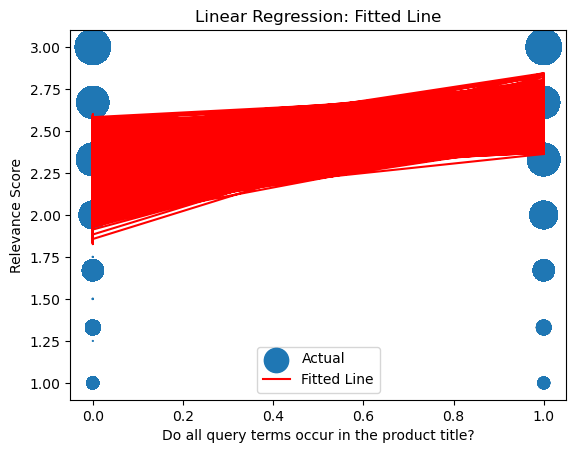

In [127]:
import matplotlib.pyplot as plt
from collections import Counter

weight_counter = Counter(y_test)
weights = [weight_counter[i]/10 for i in y_test]

plt.scatter(test_data['all_words_in_title'], y_test, label='Actual', s=weights)
plt.plot(test_data['all_words_in_title'], y_pred, color='red', label='Fitted Line')
plt.xlabel('Do all query terms occur in the product title?')
plt.ylabel('Relevance Score')
plt.title('Linear Regression: Fitted Line')
plt.legend()
plt.show()